# Analysis of Control E. Coli vs Resistant E. Coli with Antibiotics using SVM

In [1]:
%load_ext autoreload
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from numpy import loadtxt
from scipy.fftpack import fft
from scipy.fft import fft, ifft, fftfreq
from numpy import arange
from skimage.measure import EllipseModel
from matplotlib.patches import Ellipse
from scipy.signal import savgol_filter
from random import randint
%run data_import_to_create_databases.ipynb
%run functions_master_file.ipynb

empty_drums_30: Empty cavities has 828 cases.
empty_drums_graph: Empty drums has 928 cases.
ecoli_CTR: Control cases has 1130 cases.
ecoli_WA_subs: E. Coli susceptible has 380 cases.
ecoli_WA_resis: E. Coli resistant has 207 cases.
ecoli_WA_total: All E. Coli with antibiotics has 587 cases.
intact_drums: Intact drums has 2645 cases.
bacteria_all: All E. Coli data has 1717 cases.
Therefore, all data has 3473 cases.

For cases with other bacteria:

kpneumoniae_KPC2_CTR: All Klabsiella Pneumoniae data has 526 cases.
Paeruginosa_L1171_CTR: All Pseudomonas aeruginosa data has 95 cases.
abaumannii_B1380_CTR: All Acinetobacter Baumannii data has 106 cases.
S_aureus_CTR: All Staphylococcus Aureus data has 204 cases.
senteriditis_S1400_CTR: All Salmonella Enteritidis data has 198 cases.
Sagalactiae_CTR: All Streptococcus Agalactiae data has 100 cases.


## Flatten and Fix data arround zero

In [2]:
ecoli_WA_susc_array, t = flatten_fix_n_filter_data(ecoli_WA_subs, tf = ecoli7744_CTR_df['Time [s]'][0], 
                threshold_range = [0.4457498640103203, 6], flatten = True, filter_by_variance = True)

ecoli_WA_resis_array, t = flatten_fix_n_filter_data(ecoli_WA_resis, tf = ecoli7744_CTR_df['Time [s]'][0], 
                threshold_range = [20, 10000], flatten = True, filter_by_variance = True)

The data used has a shape of (244, 60000)
The data used has a shape of (102, 60000)


# Support Vector Machines with Sklearn

## Divide the measurements in Train and Test datasets

In [ ]:
case1 = suffle_index(ecoli_WA_susc_array)
case2 = suffle_index(ecoli_WA_resis_array)

case1_index = 4*len(case1) // 5
case2_index = 4*len(case2) // 5 

train_data = np.vstack((case1[:case1_index], case2[:case2_index]))
test_data = np.vstack((case1[-(len(case1)-case1_index):], case2[-(len(case2)-case2_index):]))

train_labels = np.hstack((np.zeros(train_data[:case1_index].shape[0]), np.ones(train_data[:case2_index].shape[0])))
test_labels = np.hstack((np.zeros(test_data[-(len(case1)-case1_index):].shape[0]), np.ones(test_data[-(len(case2)-case2_index):].shape[0])))

train_images, train_vmin, train_vmax, train_freqs  = get_all_Pxx_matrices(train_data, 
            tf=ecoli7744_CTR_df['Time [s]'][0], limit_Pxx_height= 32,
            nperseg_val = 2**9, noverlap_val = ((2**9)/(2)), find_scale = 'average_minmax',
            same_color_scale=True, log_scale=True)

test_images, test_vmin, test_vmax, test_freqs  = get_all_Pxx_matrices(test_data, 
            tf=ecoli7744_CTR_df['Time [s]'][0], limit_Pxx_height= 32,
            nperseg_val = 2**9, noverlap_val = ((2**9)/(2)), find_scale = 'average_minmax',
            same_color_scale=True, log_scale=True)

In [4]:
print('A dataset of ' + str(train_images.shape[0]+test_images.shape[0]) + ' measurements is used.')
print('')
print(str(train_images.shape[0]) + ' are used for training with a shape of ' + str(train_images.shape[-3:]))
print('Case 1 in traning has ' + str(case1_index) + ' cases.')
print('Case 2 in traning has ' + str(case2_index) + ' cases.')
print('')
print(str(test_images.shape[0]) + ' are used for testing with a shape of ' + str(test_images.shape[-3:]))
print('Case 1 in testing has ' + str((len(case1)-case1_index)) + ' cases.')
print('Case 2 in testing has ' + str((len(case2)-case2_index)) + ' cases.')

A dataset of 346 measurements is used.

276 are used for training with a shape of (276, 32, 233)
Case 1 in traning has 195 cases.
Case 2 in traning has 81 cases.

70 are used for testing with a shape of (70, 32, 233)
Case 1 in testing has 49 cases.
Case 2 in testing has 21 cases.


### Checking the first 10 generated images

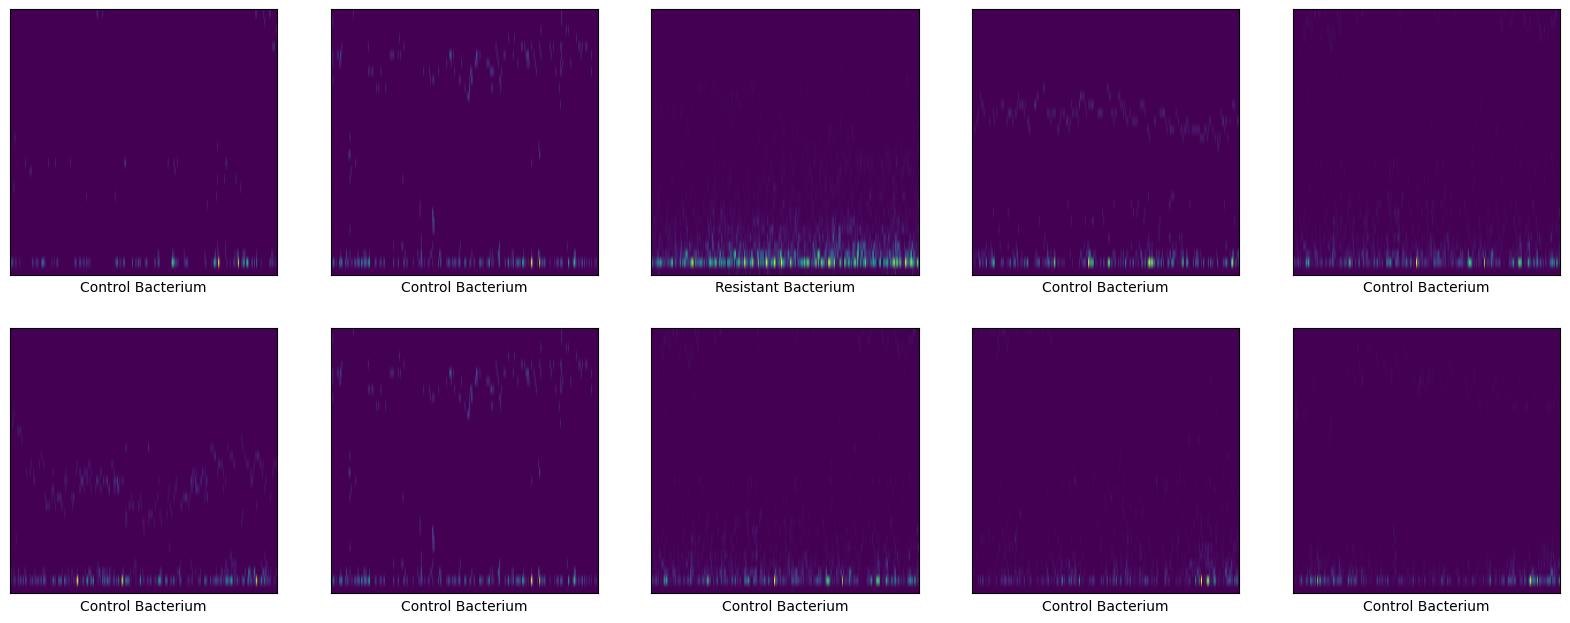

In [6]:
test_before_norm = get_some_img_in_arrays(test_images, test_labels, num_img = 10, 
                            class_names = ['Control Bacterium', 'Resistant Bacterium'],
                            colorbar_active = False, 
                            vmin_val = None, vmax_val = None)

# Support Vector Machines with Sklearn

## Case with Control E. Coli and Resistant E. Coli with antibiotics

## Reshape of the Image Arrays

Here a reshape of the arrays of the images is being done in order to flatten the matrix which has the information about the image. In the flattening, the matrix is converted into a 1D vector. 

In [ ]:
train_images_re = train_images.reshape(train_images.shape[0], train_images.shape[1]*train_images.shape[2])
test_images_re = test_images.reshape(test_images.shape[0], test_images.shape[1]*test_images.shape[2])
print(train_images_re.shape)
print(test_images_re.shape)

(276, 7456)
(70, 7456)


## Support Vector Machines Architecture

In [ ]:
from sklearn import svm
model_svc = svm.SVC(kernel='poly', degree = 4, C=1.0)

In [10]:
%%time
model_svc.fit(train_images_re, train_labels)

CPU times: user 15.1 ms, sys: 3.55 ms, total: 18.7 ms
Wall time: 18.3 ms


,C,1.0
,kernel,'poly'
,degree,4
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [ ]:
model_svc.score(test_images_re, test_labels)

0.9142857142857143

## Confusion Matrix

Raw confusion matrix:
 [[49  0]
 [ 6 15]]


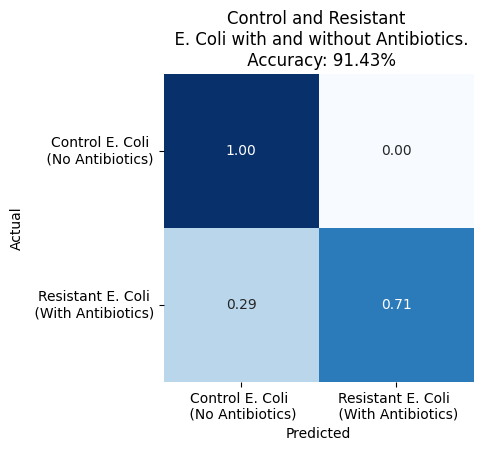

In [ ]:
target_names = ['Control E. Coli \n (No Antibiotics)', 'Resistant E. Coli \n (With Antibiotics)']

conf_matrix, accur, _ = plot_conf_matrix(model_svc, test_images_re, test_labels, algorithm_type = 'SVM',
                        title = 'Control and Resistant \n  E. Coli with and without Antibiotics',
                        file_name = 'Poly_4th_SVM_ecoli_CTR_vs_ecoli_WA_resis_nomalized_(c=1.0)_@',
                        target_names = target_names, save = False, normalize = True)

## Saving the tranined model

In [48]:
from tensorflow.keras.models import load_model
from joblib import dump, load

# Save the model
# dump(model_svc, 'Poly_4th_SVM_model_ecoli_CTR_vs_ecoli_WA_resis_acc_78_@.joblib')

# from keras.models import load_model
# model = load_model('my_model.h5')

['Poly_4th_SVM_model_ecoli_CTR_vs_ecoli_WA_resis_acc_78.joblib']

## Regularization Parameter convergence Analysis

In [24]:
from sklearn import svm
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Define a range of C values
C_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 2.0, 3.0,
            4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]

# Initialize an empty list to store the accuracies
accuracies = []

# Loop over the C values
for C in C_values:
    # Initialize and train the SVM
    model_svc = svm.SVC(kernel='linear', C=C)
    model_svc.fit(train_images_re, train_labels)
    
    # Compute the predictions on the test set
    predictions = model_svc.predict(test_images_re)
    
    # Compute the accuracy and append it to the list of accuracies
    accuracy = accuracy_score(test_labels, predictions)
    accuracies.append(accuracy)

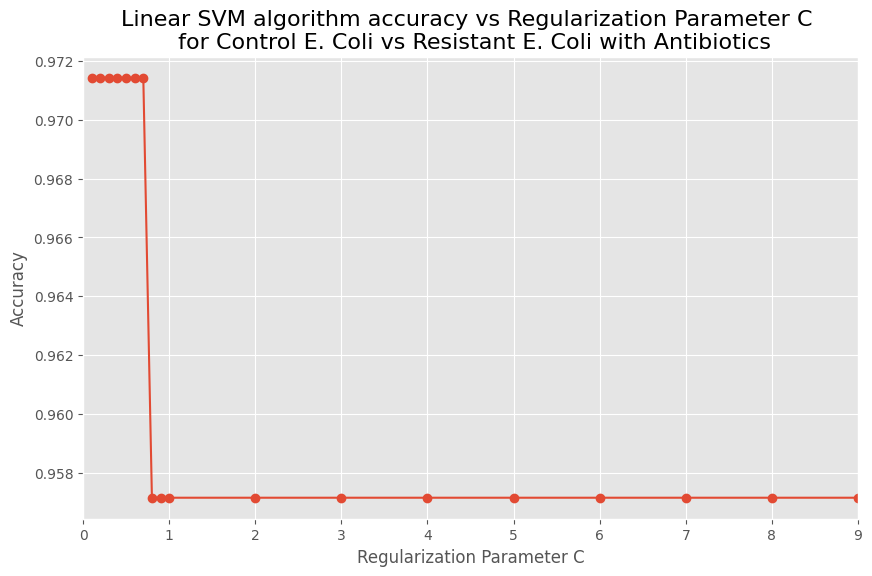

In [26]:
# Plot the accuracies as a function of the C values
set_plot_style(style_num=9)
plt.figure(figsize=(10, 6))
plt.plot(C_values, accuracies, marker='o')
plt.xlabel('Regularization Parameter C')
plt.ylabel('Accuracy')
plt.title('Linear SVM algorithm accuracy vs Regularization Parameter C \n for Control E. Coli vs Resistant E. Coli with Antibiotics', fontsize=16)
plt.xlim(0,9)
# plt.savefig('C_parameter_Poly_4th_SVM_ecoli_CTR_vs_ecoli_WA_resis_1')
plt.show()

### Convergence Analysis for the poly 4th degree kernel

In [28]:
from sklearn import svm
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Define a range of C values
C_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 2.0, 3.0,
            4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 20, 30, 40, 50, 60, 70,
            80, 90, 100, 110, 120, 130, 140, 150, 170, 180, 190, 200,
            210, 220, 230, 240, 250, 260, 270, 280, 290, 300]

# Initialize an empty list to store the accuracies
accuracies_poly = []

# Loop over the C values
for C in C_values:
    # Initialize and train the SVM
    model_svc_poly = svm.SVC(kernel='poly', degree = 4, C=C)
    model_svc_poly.fit(train_images_re, train_labels)
    
    # Compute the predictions on the test set
    predictions_poly = model_svc_poly.predict(test_images_re)
    
    # Compute the accuracy and append it to the list of accuracies
    accuracy_poly = accuracy_score(test_labels, predictions_poly)
    accuracies_poly.append(accuracy_poly)

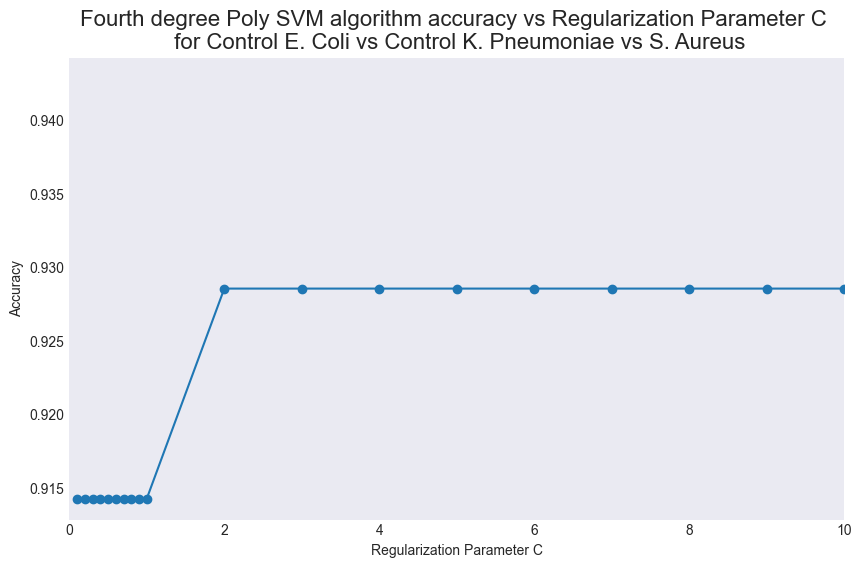

In [29]:
# Plot the accuracies as a function of the C values
set_plot_style(style_num=17)
plt.figure(figsize=(10, 6))
plt.plot(C_values, accuracies_poly, marker='o')
plt.xlabel('Regularization Parameter C')
plt.ylabel('Accuracy')
plt.title('Fourth degree Poly SVM algorithm accuracy vs Regularization Parameter C \n for Control E. Coli vs Control K. Pneumoniae vs S. Aureus', fontsize=16)
plt.xlim(0,10)
plt.grid(False)
# plt.savefig('C_parameter_Poly4th_SVM_ecoli_CTR_vs_kpneu_CTR_Saureus_Pxx_X')
plt.show()